In [ ]:
from datetime import datetime, timedelta
from dataclasses import dataclass, field, asdict
from typing import List
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


In [6]:
categories = {
    "국내주식": 145,
    "해외주식": 120,
    "채권": 85,
    "섹터": 95,
    "원자재": 25,
    "부동산": 15,
    "기타": 30,
}

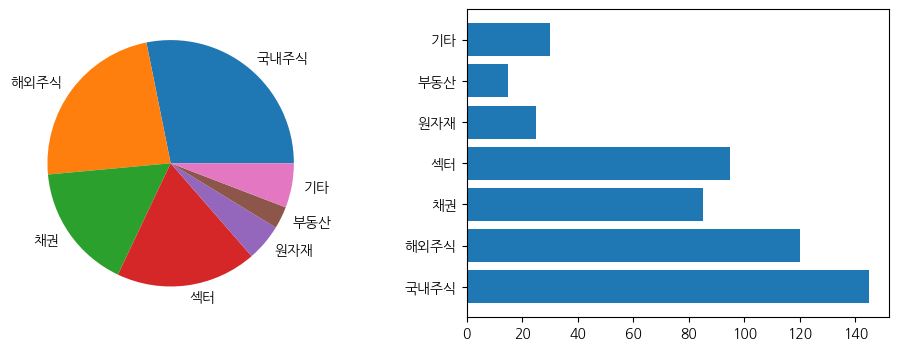

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.pie(
    categories.values(),
    labels=categories.keys(),
)
ax2.barh(list(categories.keys()), list(categories.values()))

plt.show()

In [9]:
etf_universe = [
    {"name": "KODEX 200", "cat": "국내주식", "ret_1y": 12.3, "risk": 15.2},
    {"name": "TIGER S&P500", "cat": "해외주식", "ret_1y": 18.5, "risk": 13.8},
    {"name": "KODEX 배당가치", "cat": "배당", "ret_1y": 8.2, "risk": 10.5},
    {"name": "TIGER 반도체", "cat": "섹터", "ret_1y": 35.2, "risk": 28.4},
    {"name": "KODEX 국고채3년", "cat": "채권", "ret_1y": 3.5, "risk": 2.1},
    {"name": "KODEX 골드선물", "cat": "원자재", "ret_1y": 15.8, "risk": 16.3},
    {"name": "KODEX 2차전지", "cat": "섹터", "ret_1y": -5.2, "risk": 32.1},
    {"name": "TIGER 단기통안채", "cat": "채권", "ret_1y": 3.2, "risk": 0.8},
]


In [10]:
df_etf = pd.DataFrame(etf_universe)
df_etf

,name,cat,ret_1y,risk
0,KODEX 200,국내주식,12.3,15.2
1,TIGER S&P500,해외주식,18.5,13.8
2,KODEX 배당가치,배당,8.2,10.5
3,TIGER 반도체,섹터,35.2,28.4
4,KODEX 국고채3년,채권,3.5,2.1
5,KODEX 골드선물,원자재,15.8,16.3
6,KODEX 2차전지,섹터,-5.2,32.1
7,TIGER 단기통안채,채권,3.2,0.8


In [11]:
df_etf["cat"].unique()

array(['국내주식', '해외주식', '배당', '섹터', '채권', '원자재'], dtype=object)

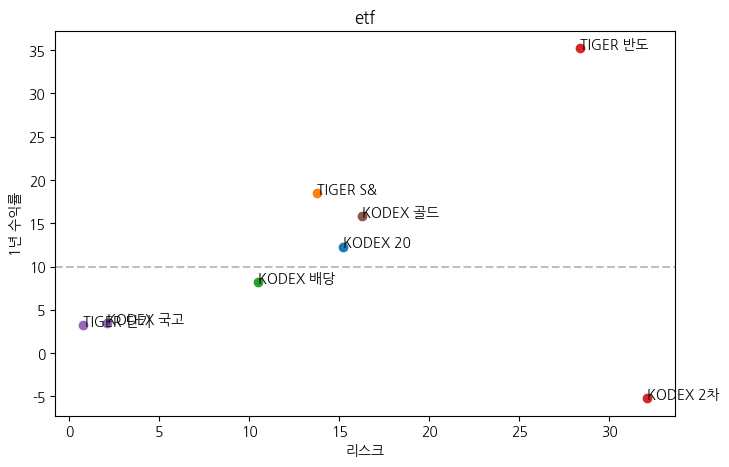

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for cat in df_etf["cat"].unique():
    sub = df_etf[df_etf["cat"] == cat]
    ax.scatter(sub["risk"], sub["ret_1y"], label=cat)
    for _, row in sub.iterrows():
        ax.annotate(row["name"][:8], (row["risk"], row["ret_1y"]))

ax.set_xlabel("리스크")
ax.set_ylabel("1년 수익률")
ax.set_title("etf")
ax.axhline(y=10, color="gray", linestyle="--", alpha=0.5)
plt.show()

In [15]:
@dataclass
class ETFSchema:  # def __init__
    ticker: str  # 00233439
    name: str
    category: str
    expense_ratio: float
    risk_level: str = "중간"
    aum_billion: float = 0.0
    description: str = ""
    keywords: List[str] = field(default_factory=list)

    def __post_init__(self):
        if self.expense_ratio < 0 or self.expense_ratio > 5:
            raise ValueError(f"수수료 범위 오류: {self.expense_ratio}")
        valid_risks = ["매우낮음", "낮음", "중간", "높음", "매우높음"]
        if self.risk_level not in valid_risks:
            raise ValueError(f"리스크 등급 오류: {self.risk_level}")  # "매우 낮음"

In [16]:
etf = ETFSchema(
    ticker="069500",
    name="KODEX 200",
    category="국내주식",
    expense_ratio=1.5,
    keywords=["코스피", "대형주", "인덱스"],
)

In [17]:
etf

ETFSchema(ticker='069500', name='KODEX 200', category='국내주식', expense_ratio=1.5, risk_level='중간', aum_billion=0.0, description='', keywords=['코스피', '대형주', '인덱스'])

In [18]:
etf_dict = asdict(etf)
etf_dict

{'ticker': '069500',
 'name': 'KODEX 200',
 'category': '국내주식',
 'expense_ratio': 1.5,
 'risk_level': '중간',
 'aum_billion': 0.0,
 'description': '',
 'keywords': ['코스피', '대형주', '인덱스']}

In [20]:
test_cases = [
    {
        "ticker": "A",
        "name": "정상",
        "category": "채권",
        "expense_ratio": 0.05,
        "risk_level": "낮음",
    },
    {
        "ticker": "B",
        "name": "수수료오류",
        "category": "주식",
        "expense_ratio": -0.5,
        "risk_level": "중간",
    },
    {
        "ticker": "C",
        "name": "리스크오류",
        "category": "원자재",
        "expense_ratio": 0.3,
        "risk_level": "최고",
    },
]

In [21]:
for tc in test_cases:
    try:
        e = ETFSchema(**tc)
        print(f" {tc['name']}: 생성 성공")
    except ValueError as err:
        print(f" {tc['name']} : {err}")

 정상: 생성 성공
 수수료오류 : 수수료 범위 오류: -0.5
 리스크오류 : 리스크 등급 오류: 최고


## FinanceDataReader

In [ ]:
import FinanceDataReader as fdr

etf_list = fdr.StockListing("etf/kr")
etf_list

,Symbol,Category,Name,Price,RiseFall,Change,ChangeRate,NAV,EarningRate,Volume,Amount,MarCap
0,069500,1,KODEX 200,90430,2,2550,2.90,90560.0,28.4924,14863983,1351020,207537
1,360750,4,TIGER 미국S&P500,25330,2,265,1.06,25291.0,-1.5438,10867442,275477,156881
2,396500,2,TIGER 반도체TOP10,34600,2,850,2.52,34824.0,45.4427,16138341,561843,94994
3,133690,4,TIGER 미국나스닥100,166875,2,2195,1.33,166394.0,-2.0232,694192,115892,84272
4,379800,4,KODEX 미국S&P500,23155,2,250,1.09,23115.0,-1.5748,13222149,306290,82710
...,...,...,...,...,...,...,...,...,...,...,...,...
1083,465620,4,ACE 미국빅테크TOP7 Plus인버스(합성),7090,5,-105,-1.46,7099.0,2.7857,796,5,18
1084,334700,5,RISE 팔라듐선물인버스(H),2925,5,-80,-2.66,2900.0,12.1268,2552,7,18
1085,412560,2,TIGER BBIG레버리지,2400,2,50,2.13,2372.0,-10.8160,9175,21,17
1086,306520,3,HANARO 200선물인버스,3460,5,-105,-2.95,3444.0,-28.9133,2276,7,12


In [28]:
ticker = "069500"
end_date = datetime.now().strftime("%Y-%m-%d")
start_date = (datetime.now() - timedelta(days=365)).strftime("%Y-%m-%d")

end_date, start_date

('2026-04-14', '2025-04-14')

In [31]:
price_df = fdr.DataReader(ticker, start_date, end_date)
price_df

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-14,32343,32570,32271,32373,5621869,0.006342
2025-04-15,32417,32781,32417,32692,8915848,0.009854
2025-04-16,32556,32614,32169,32183,7177604,-0.015570
2025-04-17,32271,32561,32203,32501,6951765,0.009881
2025-04-18,32556,32722,32452,32722,6025639,0.006800
...,...,...,...,...,...,...
2026-04-08,87850,90070,87400,89000,29329013,0.075269
2026-04-09,88310,88735,87070,87250,20553049,-0.019663
2026-04-10,88795,89805,88520,88655,12112242,0.016103


In [32]:
def collect_etf_price(ticker, days=365):
    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=days)).strftime("%Y-%m-%d")
    try:
        df = fdr.DataReader(ticker, start_date, end_date)
        if len(df) > 0:
            return {"status": "success", "data": df, "ticker": ticker}
        else:
            return {"status": "error", "message": "데이터가 없습니다."}
    except Exception as e:
        return {"status": "error", "message": str(e)}

In [33]:
collect_etf_price(ticker)

{'status': 'success',
 'data':              Open   High    Low  Close    Volume    Change
 Date                                                      
 2025-04-14  32343  32570  32271  32373   5621869  0.006342
 2025-04-15  32417  32781  32417  32692   8915848  0.009854
 2025-04-16  32556  32614  32169  32183   7177604 -0.015570
 2025-04-17  32271  32561  32203  32501   6951765  0.009881
 2025-04-18  32556  32722  32452  32722   6025639  0.006800
 ...           ...    ...    ...    ...       ...       ...
 2026-04-08  87850  90070  87400  89000  29329013  0.075269
 2026-04-09  88310  88735  87070  87250  20553049 -0.019663
 2026-04-10  88795  89805  88520  88655  12112242  0.016103
 2026-04-13  86465  88090  86410  87880  13658534 -0.008742
 2026-04-14  90245  91600  89955  90430  14863983  0.029017
 
 [244 rows x 6 columns],
 'ticker': '069500'}

## 보간법

In [39]:
sample_df = price_df.copy()
mask = np.random.random(len(sample_df)) < 0.05

In [40]:
sample_df.loc[mask, "Close"] = np.nan
sample_df["Close"].isna().sum()

np.int64(16)

In [41]:
ffill_df = sample_df.copy()
ffill_df["Close"] = ffill_df["Close"].ffill()
ffill_df["Close"].isna().sum()

np.int64(0)

In [42]:
interp_df = sample_df.copy()
interp_df["Close"] = interp_df["Close"].interpolate(method="linear")
interp_df["Close"].isna().sum()

np.int64(0)

In [47]:
rolling_df = sample_df.copy()
rolling_mean = rolling_df["Close"].rolling(window=5, min_periods=1).mean()
rolling_df["Close"] = rolling_df["Close"].fillna(rolling_mean)
rolling_df["Close"].isna().sum()

np.int64(0)

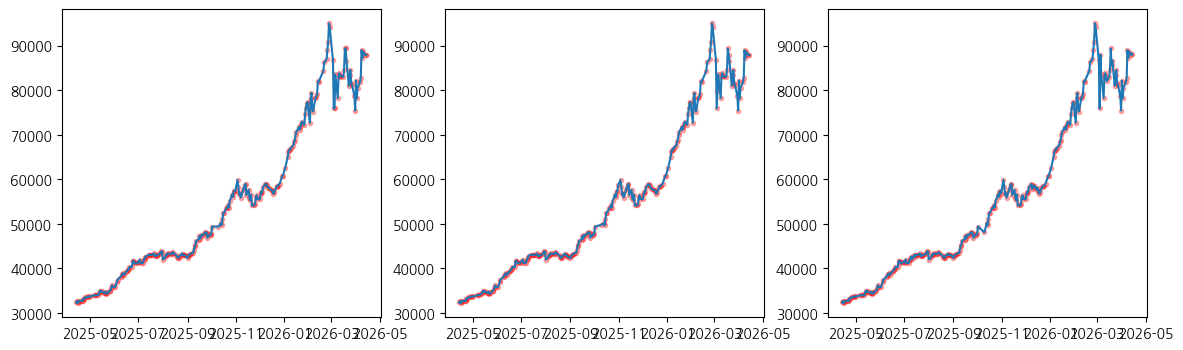

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, df, title in zip(
    axes, [ffill_df, interp_df, rolling_df], ["ffill", "linear", "rolling"]
):
    ax.plot(df.index, df["Close"], "ro", markersize=3, alpha=0.3, label="missing")
    ax.plot(df.index, df["Close"], label=title)

In [ ]:
def detect_iqr(series, factor=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - factor * iqr) | (series > q3 + factor * iqr)


def detect_z(series, threshold=3):
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

In [57]:
z_outliers = detect_z(ffill_df)
z_outliers.sum()

Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

In [58]:
iqr_outliers = detect_iqr(ffill_df)
iqr_outliers.sum()

Open       0
High       0
Low        0
Close      0
Volume    10
Change    23
dtype: int64

In [59]:
(z_outliers & iqr_outliers).sum()

Open      0
High      0
Low       0
Close     0
Volume    3
Change    7
dtype: int64

In [71]:
features = ffill_df[["Close"]].copy()
features.head()

,Close
Date,
2025-04-14,32373.0
2025-04-15,32692.0
2025-04-16,32183.0
2025-04-17,32501.0
2025-04-18,32722.0


In [72]:
features["return"] = features["Close"].pct_change()
features.head()

,Close,return
Date,,
2025-04-14,32373.0,NaN
2025-04-15,32692.0,0.009854
2025-04-16,32183.0,-0.015570
2025-04-17,32501.0,0.009881
2025-04-18,32722.0,0.006800


In [76]:
features["vol_5d"] = features["return"].rolling(5).std()
features.head(10)

,Close,return,vol_5d
Date,,,
2025-04-14,32373.0,NaN,NaN
2025-04-15,32692.0,0.009854,NaN
2025-04-16,32183.0,-0.015570,NaN
2025-04-17,32501.0,0.009881,NaN
2025-04-18,32722.0,0.006800,NaN
2025-04-21,32766.0,0.001345,0.010664
2025-04-22,32658.0,-0.003296,0.009985
2025-04-23,33247.0,0.018035,0.008172
2025-04-24,33188.0,-0.001775,0.008634


In [77]:
features["log_return"] = np.log(features["Close"] / features["Close"].shift(1))
features.head()

,Close,return,vol_5d,log_return
Date,,,,
2025-04-14,32373.0,NaN,NaN,NaN
2025-04-15,32692.0,0.009854,NaN,0.009806
2025-04-16,32183.0,-0.015570,NaN,-0.015692
2025-04-17,32501.0,0.009881,NaN,0.009832
2025-04-18,32722.0,0.006800,NaN,0.006777


In [80]:
price_df

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2025-04-14,32343,32570,32271,32373,5621869,0.006342
2025-04-15,32417,32781,32417,32692,8915848,0.009854
2025-04-16,32556,32614,32169,32183,7177604,-0.015570
2025-04-17,32271,32561,32203,32501,6951765,0.009881
2025-04-18,32556,32722,32452,32722,6025639,0.006800
...,...,...,...,...,...,...
2026-04-08,87850,90070,87400,89000,29329013,0.075269
2026-04-09,88310,88735,87070,87250,20553049,-0.019663
2026-04-10,88795,89805,88520,88655,12112242,0.016103


In [ ]:
def preprocess_pipeline(df):
    result = df[["Close"]].copy()
    # 결측치 처리(linear interpolation)
    result["Close"] = result["Close"].interpolate(method="linear")
    result["Close"] = result["Close"].ffill().bfill()
    # 이상치 처리(iqr * 1.5)
    ret = result["Close"]
    q1, q3 = ret.quantile(0.25), ret.quantile(0.75)
    iqr = q3 - q1
    outlier_mask = (ret < q1 - 1.5 * iqr) | (ret > q3 + 1.5 * iqr)
    result.loc[outlier_mask, "Close"] = np.nan
    result["Close"] = result["Close"].ffill()
    # feature engineering (return, log_return)
    result["return"] = result["Close"].pct_change()
    result["log_return"] = np.log(result["Close"] / result["Close"].shift(1))
    return result


preprocess_pipeline(sample_df).head()

,Close,return,log_return
Date,,,
2025-04-14,32373.0,NaN,NaN
2025-04-15,32692.0,0.009854,0.009806
2025-04-16,32183.0,-0.015570,-0.015692
2025-04-17,32501.0,0.009881,0.009832
2025-04-18,32722.0,0.006800,0.006777


## 시계열 데이터